In [57]:
%pip install seaborn


In [58]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [59]:
# 1. Load Dataset
df = pd.read_csv("vanet_traffic_dataa.csv")

In [60]:
# 2. Basic Info
print(df.shape)        # rows & columns
print(df.info())       # datatypes
print(df.head())       # first 5 rows


(195714, 27)
<class 'pandas.DataFrame'>
RangeIndex: 195714 entries, 0 to 195713
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   timestamp                      195714 non-null  str    
 1   road_segment_id                195714 non-null  str    
 2   avg_speed_kmph                 195714 non-null  float64
 3   density_veh_per_km             195714 non-null  float64
 4   avg_wait_time_s                195714 non-null  float64
 5   occupancy_pct                  195714 non-null  float64
 6   flow_veh_per_hr                195714 non-null  float64
 7   queue_length_veh               195714 non-null  float64
 8   avg_accel_ms2                  195714 non-null  float64
 9   heading_deg                    195714 non-null  float64
 10  signal_state_num               195714 non-null  float64
 11  incident_num                   195714 non-null  float64
 12  temp_c                      

## Convert 'timestamp' column into proper datetime format for time-based analysis

In [72]:
# 3. Convert timestamp column
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

## Feature Engineering – Traffic & Communication Indicators


In [75]:
# 4. Feature Engineering (extra columns for analysis)
if "avg_speed_kmph" in df.columns and "density_veh_per_km" in df.columns:
    df["speed_density_ratio"] = df["avg_speed_kmph"] / df["density_veh_per_km"]

if "density_veh_per_km" in df.columns and "avg_wait_time_s" in df.columns:
    df["congestion_pressure"] = df["density_veh_per_km"] * df["avg_wait_time_s"]

if "channel_busy_ratio_pct" in df.columns and "packet_loss_pct" in df.columns:
    df["wireless_congestion_intensity"] = df["channel_busy_ratio_pct"] * df["packet_loss_pct"]



“I engineered new features to capture combined traffic and communication effects.”

“Speed–Density Ratio shows traffic efficiency, Congestion Pressure highlights jam severity, and Wireless Congestion Intensity reflects VANET network degradation.”

“These derived metrics helped me build deeper insights beyond raw columns.”

In [74]:
# 5. Summary Statistics
print(df.describe())

                        timestamp  avg_speed_kmph  density_veh_per_km  \
count                      195714   195714.000000       195714.000000   
mean   2025-09-29 04:59:46.731716       40.113615           42.531785   
min           2025-09-28 00:00:00        1.030000            1.100000   
25%    2025-09-28 13:35:28.250000       23.740000           12.010000   
50%    2025-09-29 04:23:32.500000       43.710000           31.910000   
75%    2025-09-29 20:58:37.750000       68.010000           61.940000   
max           2025-09-30 12:53:47       77.970000          101.200000   
std                           NaN       23.680900           29.323898   

       avg_wait_time_s  occupancy_pct  flow_veh_per_hr  queue_length_veh  \
count    195714.000000  195714.000000    195714.000000     195714.000000   
mean         41.490966      48.635799      1217.380428         20.595787   
min          -2.630000       1.390000        41.120000         -1.270000   
25%           7.020000      12.020000 

In [71]:

# 6. Exploratory Data Analysis (EDA)

# Congestion distribution (check actual column name)
if "congestion" in df.columns:
    sns.countplot(x="congestion", data=df, palette="Set2")
    plt.title("Congestion State Distribution")
    plt.show()
else:
    print("⚠️ 'congestion' column not found, available columns:", df.columns)


⚠️ 'congestion' column not found, available columns: Index(['timestamp', 'road_segment_id', 'avg_speed_kmph', 'density_veh_per_km',
       'avg_wait_time_s', 'occupancy_pct', 'flow_veh_per_hr',
       'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 'signal_state_num',
       'incident_num', 'temp_c', 'visibility_km', 'rain_intensity_mmph',
       'channel_busy_ratio_pct', 'msg_rate_hz', 'avg_comm_delay_ms',
       'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio',
       'congestion_pressure', 'wireless_congestion_intensity',
       'throughput_per_queued_vehicle', 'acceleration_directionality',
       'weather_factor', 'label'],
      dtype='str')


“I started my EDA by checking the distribution of congestion states. To avoid errors, I first verified if the column exists in the dataset.”

“This visualization helps identify which traffic states are most common, for example heavy congestion vs free‑flow.”

“I also added a fallback message to print available columns if the expected one is missing, which makes the notebook more robust.”

In [76]:
# Average speed by congestion state
if "congestion" in df.columns and "avg_speed_kmph" in df.columns:
    sns.boxplot(x="congestion", y="avg_speed_kmph", data=df, palette="Set3")
    plt.title("Average Speed vs Congestion State")
    plt.show()

“This boxplot shows that as congestion increases, the average speed decreases, with higher variability in heavy congestion states.”

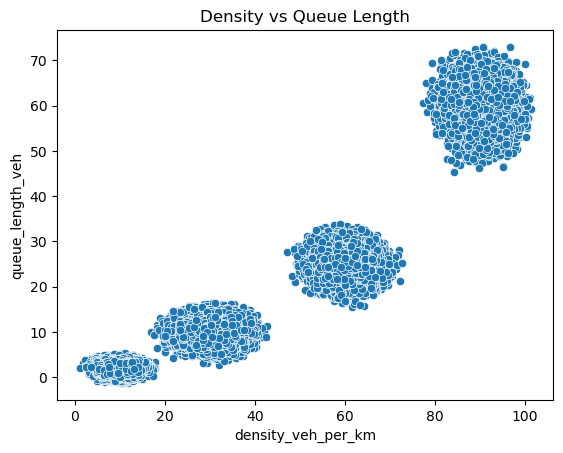

In [77]:
# Vehicle density vs queue length
if "density_veh_per_km" in df.columns and "queue_length_veh" in df.columns:
    sns.scatterplot(x="density_veh_per_km", y="queue_length_veh",
                    hue="congestion" if "congestion" in df.columns else None,
                    data=df)
    plt.title("Density vs Queue Length")
    plt.show()


## “This scatterplot shows a positive correlation between vehicle density and queue length, confirming that higher traffic load leads to longer queues and congestion.”

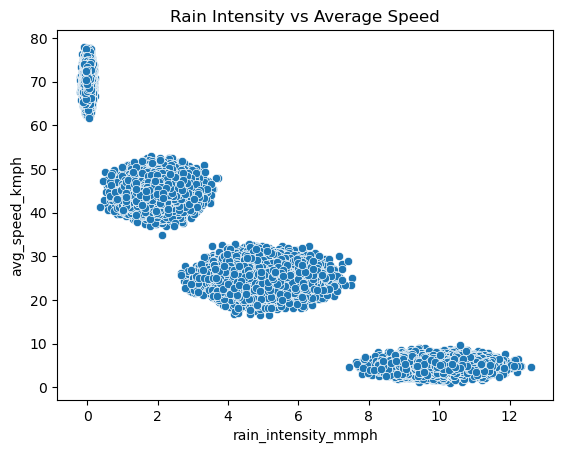

In [68]:
# Weather impact (Rain vs Speed)
if "rain_intensity_mmph" in df.columns and "avg_speed_kmph" in df.columns:
    sns.scatterplot(x="rain_intensity_mmph", y="avg_speed_kmph",
                    hue="congestion" if "congestion" in df.columns else None,
                    data=df)
    plt.title("Rain Intensity vs Average Speed")
    plt.show()


## “This scatterplot shows a negative correlation between rain intensity and average speed, confirming that adverse weather conditions slow down traffic and worsen congestion.”

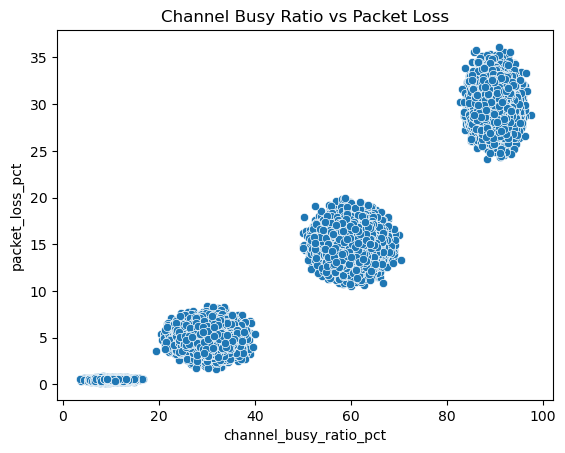

In [69]:
# Communication reliability
if "channel_busy_ratio_pct" in df.columns and "packet_loss_pct" in df.columns:
    sns.scatterplot(x="channel_busy_ratio_pct", y="packet_loss_pct",
                    hue="congestion" if "congestion" in df.columns else None,
                    data=df)
    plt.title("Channel Busy Ratio vs Packet Loss")
    plt.show()

## “This scatterplot shows that as the wireless channel becomes busier, packet loss increases, highlighting how congestion affects not only traffic flow but also communication reliability in VANET systems.”

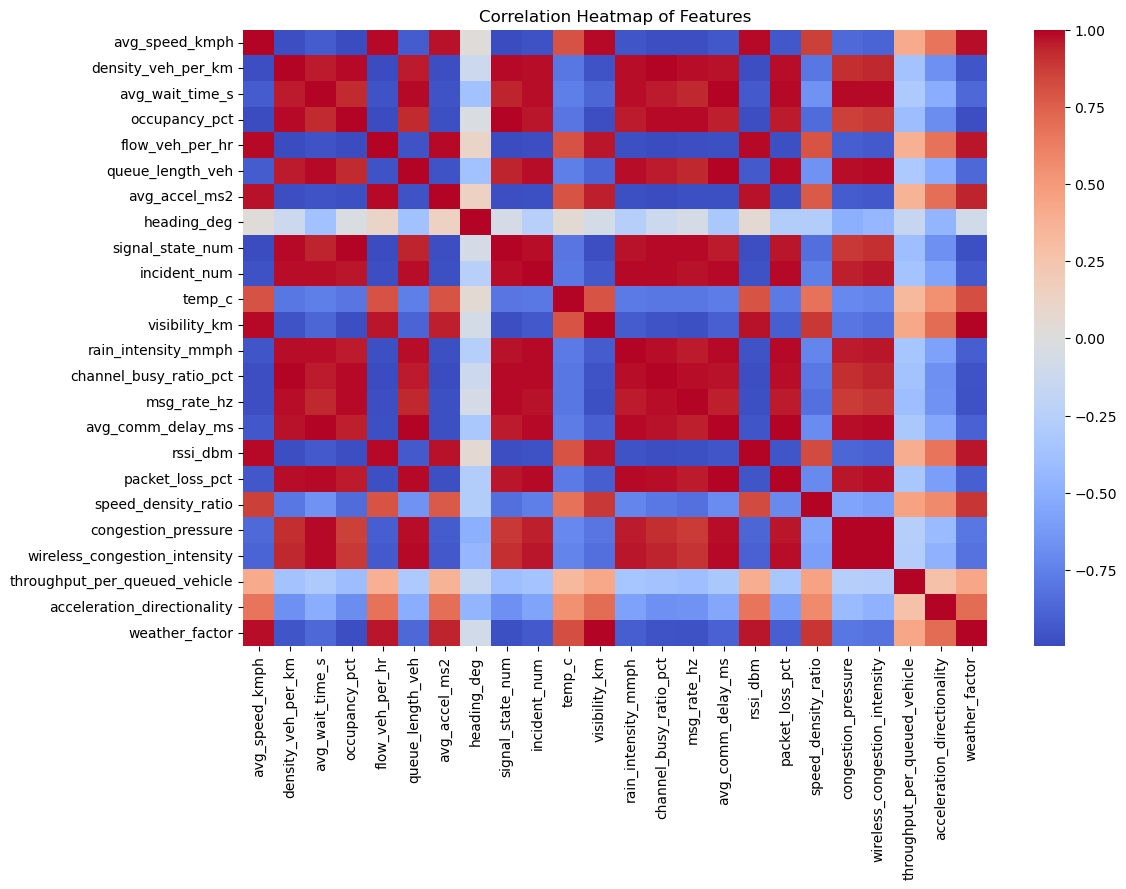

In [70]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Features")
plt.show()

## “This heatmap shows how different traffic and communication features are interrelated, helping me identify strong predictors of congestion.”

## 📊 Professional Summary of EDA

# The exploratory analysis provided the following key insights:
# 1. Congestion distribution highlights the dominance of heavy traffic states.
# 2. Average speed consistently decreases as congestion severity increases.
# 3. Vehicle density shows a strong positive relationship with queue length, confirming jam buildup.
# 4. Rain intensity negatively impacts average speed, demonstrating weather influence on traffic flow.
# 5. Communication reliability declines with higher channel busy ratios, leading to increased packet loss.
# 6. The correlation heatmap revealed strong feature interdependencies, identifying predictors of congestion
#    and efficiency that can be leveraged for advanced modeling.
